#### Week 2: Classical NLP and Embedding-Based Models

In [3]:
import scipy
print(scipy.__version__)

1.12.0


In [4]:
from gensim.models import Word2Vec

print("Working!")

Working!


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from gensim.models import Word2Vec

In [6]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")

In [7]:
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]','',text)
    return text

In [9]:
train_df["clean_text"] = train_df["Description"].apply(clean_text)
test_df["clean_text"] = test_df["Description"].apply(clean_text)

TF-IDF Feature Extraction

In [10]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [11]:
X_train = tfidf.fit_transform(
    train_df["clean_text"]
)

X_test = tfidf.transform(
    test_df["clean_text"]
)

y_train = train_df["Class Index"]
y_test = test_df["Class Index"]

Train Logistic Regression

In [12]:
lr = LogisticRegression(
    max_iter=1000
)
lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

prediction:

In [13]:
pred_lr = lr.predict(X_test)

Evaluate Logistic Regression

In [14]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           1       0.91      0.89      0.90      1900
           2       0.94      0.97      0.95      1900
           3       0.86      0.86      0.86      1900
           4       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



In [15]:
accuracy_lr = accuracy_score(
    y_test,
    pred_lr
)

Logistic Regression Confusion Matrix

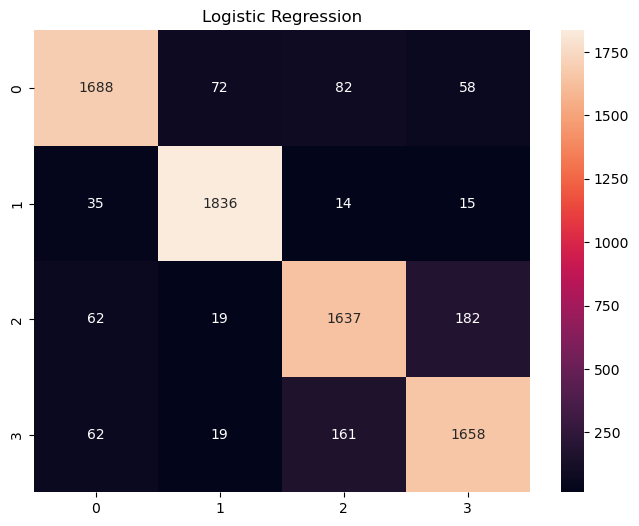

In [16]:
cm = confusion_matrix(
    y_test,
    pred_lr
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression"
)

plt.show()

In [17]:
plt.savefig(
    "confusion_matrix_lr.png"
)

<Figure size 640x480 with 0 Axes>

Train SVM

In [18]:
svm = LinearSVC()

svm.fit(
    X_train,
    y_train
)

c:\Users\Mahi\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC()

In [19]:
pred_svm = svm.predict(
    X_test
)

Evaluate SVM

In [20]:
print(
    classification_report(
        y_test,
        pred_svm
    )
)

              precision    recall  f1-score   support

           1       0.91      0.89      0.90      1900
           2       0.94      0.96      0.95      1900
           3       0.86      0.87      0.86      1900
           4       0.87      0.86      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [21]:
accuracy_svm = accuracy_score(
    y_test,
    pred_svm
)

SVM Confusion Matrix

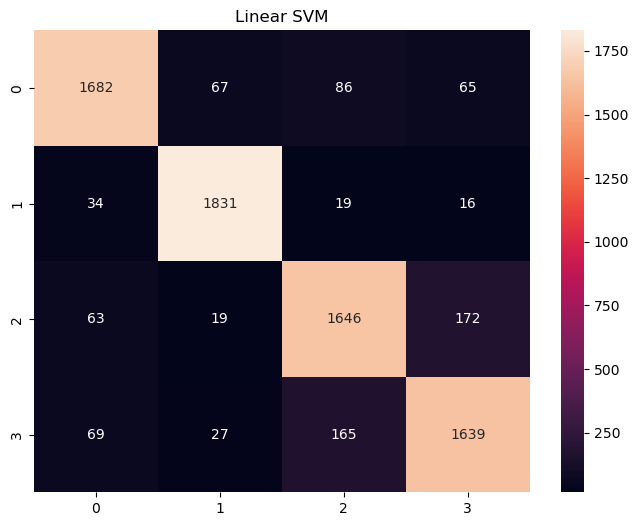

In [22]:
cm = confusion_matrix(
    y_test,
    pred_svm
)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Linear SVM")
plt.show()

In [23]:
plt.savefig(
    "confusion_matrix_svm.png"
)

<Figure size 640x480 with 0 Axes>

Word2Vec Embedding

In [24]:
sentences = train_df[
    "clean_text"
].apply(
    lambda x: x.split()
)

In [25]:
w2v = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2
)

In [26]:
#Create Document Vectors
def document_vector(text):

    words = text.split()

    vectors = [
        w2v.wv[word]
        for word in words
        if word in w2v.wv
    ]

    if len(vectors)==0:
        return np.zeros(100)

    return np.mean(
        vectors,
        axis=0
    )

In [ ]:
X_train_w2v = np.array(
    train_df["clean_text"]
    .apply(document_vector)
    .tolist()
)

X_test_w2v = np.array(
    test_df["clean_text"]
    .apply(document_vector)
    .tolist()
)+

Train Logistic Regression on Word2Vec

In [28]:
lr_embed = LogisticRegression(
    max_iter=1000
)

lr_embed.fit(
    X_train_w2v,
    y_train
)

LogisticRegression(max_iter=1000)

In [29]:
pred_embed = lr_embed.predict(
    X_test_w2v
)

Evaluate Word2Vec Model

In [30]:
print(
    classification_report(
        y_test,
        pred_embed
    )
)

              precision    recall  f1-score   support

           1       0.87      0.87      0.87      1900
           2       0.92      0.95      0.93      1900
           3       0.82      0.80      0.81      1900
           4       0.81      0.81      0.81      1900

    accuracy                           0.86      7600
   macro avg       0.85      0.86      0.85      7600
weighted avg       0.85      0.86      0.85      7600




Calculate Metrics

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Logistic Regression Metrics
acc_lr = accuracy_score(y_test, pred_lr)
prec_lr = precision_score(y_test, pred_lr, average='weighted')
rec_lr = recall_score(y_test, pred_lr, average='weighted')
f1_lr = f1_score(y_test, pred_lr, average='weighted')

# SVM Metrics
acc_svm = accuracy_score(y_test, pred_svm)
prec_svm = precision_score(y_test, pred_svm, average='weighted')
rec_svm = recall_score(y_test, pred_svm, average='weighted')
f1_svm = f1_score(y_test, pred_svm, average='weighted')

In [33]:
acc_w2v = accuracy_score(y_test, pred_embed)
prec_w2v = precision_score(y_test, pred_embed, average='weighted')
rec_w2v = recall_score(y_test, pred_embed, average='weighted')
f1_w2v = f1_score(y_test, pred_embed, average='weighted')

In [34]:
results = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'TF-IDF + Linear SVM',
        'Word2Vec + Logistic Regression'
    ],
    
    'Accuracy': [
        round(acc_lr, 4),
        round(acc_svm, 4),
        round(acc_w2v, 4)
    ],
    
    'Precision': [
        round(prec_lr, 4),
        round(prec_svm, 4),
        round(prec_w2v, 4)
    ],
    
    'Recall': [
        round(rec_lr, 4),
        round(rec_svm, 4),
        round(rec_w2v, 4)
    ],
    
    'F1 Score': [
        round(f1_lr, 4),
        round(f1_svm, 4),
        round(f1_w2v, 4)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.8972,0.8971,0.8972,0.8971
1,TF-IDF + Linear SVM,0.8945,0.8944,0.8945,0.8943
2,Word2Vec + Logistic Regression,0.8553,0.8546,0.8553,0.8548


In [35]:
results.to_csv(
    'results/model_comparison.csv',
    index=False
)

In [36]:
results.style.background_gradient(cmap='Blues')

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.897200,0.897100,0.897200,0.897100
1,TF-IDF + Linear SVM,0.894500,0.894400,0.894500,0.894300
2,Word2Vec + Logistic Regression,0.855300,0.854600,0.855300,0.854800


In [37]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

In [ ]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.8972,0.8971,0.8972,0.8971
1,TF-IDF + Linear SVM,0.8945,0.8944,0.8945,0.8943
2,Word2Vec + Logistic Regression,0.8553,0.8546,0.8553,0.8548


Find Wrong Predictions

In [39]:
errors = test_df[y_test != pred_svm].copy()

In [40]:
print("Total Misclassified Samples:", len(errors))

Total Misclassified Samples: 802


In [41]:
#Add Actual and Predicted Labels
errors["Actual"] = y_test[y_test != pred_svm].values
errors["Predicted"] = pred_svm[y_test != pred_svm]

In [42]:
errors[
    ["Description", "Actual", "Predicted"]
].head(20)

,Description,Actual,Predicted
3,AP - It's barely dawn when Mike Fitzpatrick st...,4,2
19,update Earnings per share rise compared with a...,4,3
20,"By the end of the year, the computing giant pl...",4,3
23,Google has billed its IPO as a way for everyda...,4,3
24,By MICHAEL LIEDTKE SAN FRANCISCO (AP) -- W...,4,1
36,Supporters and rivals warn of possible fraud; ...,1,3
41,Reuters - Apparel retailers are hoping their\b...,3,4
47,HONG KONG (Reuters) - Dell Inc. &lt;DELL.O&gt...,4,3
55,As Michael Kaleko kept running into people who...,4,2
56,AFP - India's Tata Iron and Steel Company Ltd....,1,3


In [43]:
errors.to_csv(
    "results/error_analysis.csv",
    index=False
)

In [44]:
errors.head()

,Class Index,Title,Description,clean_text,Actual,Predicted
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,ap its barely dawn when mike fitzpatrick star...,4,2
19,4,"Storage, servers bruise HP earnings",update Earnings per share rise compared with a...,update earnings per share rise compared with a...,4,3
20,4,IBM to hire even more new workers,"By the end of the year, the computing giant pl...",by the end of the year the computing giant pla...,4,3
23,4,Some People Not Eligible to Get in on Google IPO,Google has billed its IPO as a way for everyda...,google has billed its ipo as a way for everyda...,4,3
24,4,Rivals Try to Turn Tables on Charles Schwab,By MICHAEL LIEDTKE SAN FRANCISCO (AP) -- W...,by michael liedtke san francisco ap with ...,4,1


Category-wise Error Analysis

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred_svm
)

print(cm) #Business → Sci/Tech ,Sci/Tech → Business

[[1682   67   86   65]
 [  34 1831   19   16]
 [  63   19 1646  172]
 [  69   27  165 1639]]


## Error Analysis

The SVM model achieved the best overall performance.

Observations:

1. Most errors occurred between Business and Sci/Tech categories.

2. Articles discussing technology companies such as Apple, Google, and Microsoft were sometimes classified as either Business or Sci/Tech.

3. World and Business articles occasionally overlapped when discussing international trade and economic policies.

4. Sports articles had the fewest errors due to distinctive sports-related vocabulary.

5. Overall, the model demonstrated strong classification performance with only a small number of misclassified examples.